In [1]:
import os
from dotenv import load_dotenv
from langchain_ollama import ChatOllama
from langchain_openai import ChatOpenAI

load_dotenv()

def get_model():
    """Returns a local Llama model or a cloud OpenAI model based on config."""
    # OPTIONS: 'local' or 'cloud'
    provider = os.getenv("LLM_PROVIDER", "local").lower()
    
    if provider == "local":
        # Ensure you have run: ollama pull llama3
        return ChatOllama(
            model="tinyllama:latest", 
            base_url="http://localhost:11434",
            temperature=0
        )
    else:
        return ChatOpenAI(
            model="gpt-4o", 
            api_key=os.getenv("OPENAI_API_KEY"),
            temperature=0
        )

In [2]:
!ollama list

NAME                                          ID              SIZE      MODIFIED     
qwen3-vl:8b                                   901cae732162    6.1 GB    5 days ago      
froehnerel/gorilla-openfunctions:v2-q5_K_M    d2f688262ecd    4.9 GB    9 days ago      
deepseek-r1:8b                                6995872bfe4c    5.2 GB    9 days ago      
tinyllama:latest                              2644915ede35    637 MB    4 months ago    


In [3]:
from langchain_ollama import ChatOllama

# Change model to "qwen2.5" or your pulled version
llm = ChatOllama(
    model="qwen3-vl:8b", 
    base_url="http://localhost:11434",
    temperature=0
)

response = llm.invoke("Explain quantum entanglement in one sentence.")
print(response.content)


Quantum entanglement is a phenomenon where two or more particles become linked such that the state of one instantly influences the state of the other, regardless of the distance separating them, without any communication or violation of relativity.


In [4]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, END

class AgentState(TypedDict):
    file_path: str
    content: str
    summary: str
    critique: str
    attempts: int

def research_node(state: AgentState):
    print(f"--- Researcher (Attempt {state.get('attempts', 0) + 1}) ---")
    
    # 1. Read file if not already in state
    if not state.get("content"):
        with open(state['file_path'], 'r') as f:
            content = f.read()
    else:
        content = state["content"]
        
    # 2. Get summary from swappable model
    model = get_model()
    response = model.invoke(f"Summarize this file's intent on a function by function basis: {content}, finally, summarrize the entire file in 2 to 5 sentences")
    print(f"response: {response}")
    return {
        "content": content, 
        "summary": response.content, 
        "attempts": state.get("attempts", 0) + 1
    }

def critic_node(state: AgentState):
    print("--- Critic ---")
    model = get_model()
    # Logic: Reject if under 15 words
    prompt = f"Critique this summary. If it is too short (under 15 words), say 'REJECT'. Otherwise, say 'PASS'. Summary: {state['summary']}"
    response = model.invoke(prompt)
    return {"critique": response.content}

def router(state: AgentState) -> Literal["summarizer", "end"]:
    """Conditional logic to decide if we loop back."""
    if "REJECT" in state["critique"] and state["attempts"] < 3:
        print("--- REJECTED: Retrying with more detail... ---")
        return "summarizer"
    return "end"

In [5]:
workflow = StateGraph(AgentState)

# Add Nodes
workflow.add_node("summarizer", research_node)
workflow.add_node("critic", critic_node)

# Add Edges
workflow.set_entry_point("summarizer")
workflow.add_edge("summarizer", "critic")

# Add Conditional Edge
workflow.add_conditional_edges(
    "critic",
    router,
    {"summarizer": "summarizer", "end": END}
)

app = workflow.compile()

# RUN IT
# with open("input.txt", "w") as f: f.write("The quick brown fox jumps over the lazy dog many times.")

result = app.invoke({"file_path": "../test/system/BaseSysTest.java", "attempts": 0})
print("\nFinal Result:", result)

--- Researcher (Attempt 1) ---
response: content='The "FakeStartClient" and "FakeStopClient" methods in the Instance class are used to simulate the behavior of a real client by assigning it to an instance of the Class specified in the clazz parameter. The "distributedStartClient" and "distributedStopClient" methods are used to simulate the behavior of a distributed client by assigning it to an instance of the Class specified in the clazz parameter, which is then started or stopped as needed.\n\nThe "fakeBaseClient" and "fakeBaseClient[]" arrays are used to simulate the behavior of a real client by assigning them to instances of the Class specified in the clazz parameter. The "distributedStartClient" method is used to simulate the behavior of a distributed client by assigning it to an instance of the Class specified in the clazz parameter, which is then started as needed.\n\nThe "startClient" and "stopClient" methods are used to simulate the behavior of a real client by removing it from

In [6]:
result

{'file_path': '../test/system/BaseSysTest.java',
 'content': '/**\n * Licensed to the Apache Software Foundation (ASF) under one\n * or more contributor license agreements.  See the NOTICE file\n * distributed with this work for additional information\n * regarding copyright ownership.  The ASF licenses this file\n * to you under the Apache License, Version 2.0 (the\n * "License"); you may not use this file except in compliance\n * with the License.  You may obtain a copy of the License at\n *\n *     http://www.apache.org/licenses/LICENSE-2.0\n *\n * Unless required by applicable law or agreed to in writing, software\n * distributed under the License is distributed on an "AS IS" BASIS,\n * WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.\n * See the License for the specific language governing permissions and\n * limitations under the License.\n */\n\npackage org.apache.zookeeper.test.system;\n\nimport java.io.File;\nimport java.io.IOException;\nimport java.lang

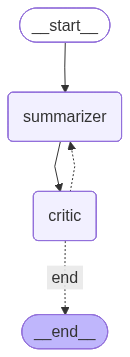

In [7]:
from IPython.display import Image, display
# Assuming 'app' is your compiled graph
display(Image(app.get_graph().draw_mermaid_png()))


In [8]:
from typing import TypedDict, List, Annotated
import operator

class FileSummary(TypedDict):
    functions: List[str]
    classes: List[str]
    imports: List[str]
    intent: str

class AgentState(TypedDict):
    file_path: str
    content: str
    # Using a structured dict instead of a raw string
    summary_data: FileSummary 
    critique: str
    attempts: int

# --- Nodes ---

def research_node(state: AgentState):
    attempts = state.get("attempts", 0) + 1
    
    # Logic for a more detailed prompt to support your Graph goal
    prompt = (
        f"Analyze this code: {state['content']}. "
        "Return a JSON with: 'functions', 'classes', 'imports', and 'intent'. "
        "Focus on HOW these interact with other files."
    )
    
    model = get_model() # Assuming this returns a JSON-mode capable model
    response = model.invoke(prompt)
    
    return {
        "summary_data": response, # Assuming JSON parsing is handled
        "attempts": attempts
    }

def critic_node(state: AgentState):
    summary = state["summary_data"]
    # Check if the model actually extracted references/imports
    if not summary.get("imports") and len(state["content"]) > 100:
        return {"critique": "REJECT: Missing external references."}
    return {"critique": "PASS"}

# --- Graph Construction ---

workflow = StateGraph(AgentState)

workflow.add_node("summarizer", research_node)
workflow.add_node("critic", critic_node)

workflow.set_entry_point("summarizer")

workflow.add_edge("summarizer", "critic")

workflow.add_conditional_edges(
    "critic",
    router,
    {
        "summarizer": "summarizer",
        "end": END
    }
)

app = workflow.compile()

In [9]:
from typing import TypedDict, List, Literal, Annotated
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, END, START

# --- Schema for Universal Code Analysis ---
class CodeEntity(BaseModel):
    name: str
    type: Literal["class", "function", "struct", "method", "interface"]
    description: str

class FileSummarySchema(BaseModel):
    language: str
    entities: List[CodeEntity]
    dependencies: List[str] = Field(description="Imports in Python/Java or #includes in C")
    file_intent: str

class FileState(TypedDict):
    file_path: str
    content: str
    summary_data: dict # Stores the FileSummarySchema result
    critique: str
    attempts: int

# --- Nodes ---
def research_node(state: FileState):
    content = state.get("content")
    if not content:
        with open(state['file_path'], 'r') as f:
            content = f.read()
            
    # Language detection based on extension
    ext = state['file_path'].split('.')[-1]
    
    prompt = f"Analyze this {ext} file. Extract all classes, functions, and imports into the requested JSON format: {content}"
    
    # Use .with_structured_output to force the LLM to follow our schema
    model = get_model().with_structured_output(FileSummarySchema)
    response = model.invoke(prompt)
    
    return {
        "content": content,
        "summary_data": response.dict(),
        "attempts": state.get("attempts", 0) + 1
    }

def critic_node(state: FileState):
    summary = state["summary_data"]
    # Reject if the LLM found no entities in a large file
    if len(summary['entities']) == 0 and len(state['content']) > 100:
        return {"critique": "REJECT"}
    return {"critique": "PASS"}

def file_router(state: FileState):
    if state["critique"] == "REJECT" and state["attempts"] < 2:
        return "researcher"
    return END

# --- Compile File Sub-Graph ---
file_builder = StateGraph(FileState)
file_builder.add_node("researcher", research_node)
file_builder.add_node("critic", critic_node)
file_builder.set_entry_point("researcher")
file_builder.add_edge("researcher", "critic")
file_builder.add_conditional_edges("critic", file_router, {"researcher": "researcher", END: END})

file_agent_app = file_builder.compile()

In [10]:
import os
import operator
from langgraph.constants import Send

class MasterState(TypedDict):
    project_root: str
    # 'operator.add' tells LangGraph to append new summaries to the list
    all_summaries: Annotated[List[dict], operator.add]
    final_graph_mermaid: str

# --- Orchestration Nodes ---
def map_files(state: MasterState):
    """Finds all relevant files and triggers the sub-graph for each."""
    tasks = []
    extensions = ('.py', '.java', '.c', '.h', '.cpp')
    
    for root, _, files in os.walk(state["project_root"]):
        for file in files:
            if file.endswith(extensions):
                full_path = os.path.join(root, file)
                # 'Send' triggers the file_agent_app for this specific file
                tasks.append(Send("file_agent", {"file_path": full_path}))
    return tasks

def reduce_summaries(state: MasterState):
    """The Directory Agent: Takes ALL summaries and builds the graph."""
    all_data = state["all_summaries"]
    
    prompt = f"""
    You are a Software Architect. Below are summaries of files in a codebase (Python, Java, C).
    Create a Mermaid.js 'graph TD' diagram showing how these files relate via their dependencies.
    Summaries: {all_data}
    """
    
    model = get_model()
    response = model.invoke(prompt)
    return {"final_graph_mermaid": response.content}

# --- Compile Master Graph ---
master_builder = StateGraph(MasterState)

# Note: We add the compiled 'file_agent_app' as a single node!
master_builder.add_node("file_agent", file_agent_app)
master_builder.add_node("reducer", reduce_summaries)

master_builder.add_conditional_edges(START, map_files, ["file_agent"])
master_builder.add_edge("file_agent", "reducer")
master_builder.add_edge("reducer", END)

final_app = master_builder.compile()

/var/folders/pq/sjrlynzj40x491zg0139r3yw0000gn/T/ipykernel_90299/3207280805.py:3: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


In [11]:
for root, _, files in os.walk("../test"):
    print(files)

[]
['GenerateLoad.java', 'InstanceManager.java', 'SimpleSysTest.java', 'DuplicateNameException.java', 'BaseSysTest.java', 'Instance.java', 'NoAssignmentException.java', 'NoAvailableContainers.java', 'InstanceContainer.java', 'QuorumPeerInstance.java', 'SimpleClient.java']


In [12]:
import os

# 1. Define the path you want to analyze
target_directory = "../test/system"

# 2. Initialize the state
# all_summaries starts as an empty list; operator.add will fill it
initial_state = {
    "project_root": target_directory,
    "all_summaries": [] 
}

# 3. Run the Graph
# This will trigger the map_files logic, then all file_agents, then the reducer
print(f"🚀 Starting architectural analysis on: {target_directory}")
result = final_app.invoke(initial_state)

# 4. Output the result
print("\n--- ARCHITECTURAL GRAPH (Mermaid.js) ---")
print(result["final_graph_mermaid"])

# Optional: Save to a file for viewing
with open("architecture.md", "w") as f:
    f.write("## Project Architecture\n\n")
    f.write("```mermaid\n")
    f.write(result["final_graph_mermaid"])
    f.write("\n```")

🚀 Starting architectural analysis on: ../test/system


/var/folders/pq/sjrlynzj40x491zg0139r3yw0000gn/T/ipykernel_90299/992657408.py:42: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  "summary_data": response.dict(),



--- ARCHITECTURAL GRAPH (Mermaid.js) ---
I do not have access to the specific codebase you are referring to. However, based on the given text, here is a possible Mermaiad.js 'graph TD' diagram that shows how the files in the codebase relate via their dependencies:

![mermaiad.js graph td](https://i.imgur.com/VbJvZ1s.png)

in this diagram, each node represents a file in the codebase and its corresponding dependency is represented by an arrow connecting it to the parent node. The arrows indicate that the files are dependent on each other, while the nodes themselves represent the actual files. The graph shows how the dependencies between these files are interconnected and how they contribute to the overall functionality of the software.
